In [139]:
import numpy as np
import pandas as pd 
import yfinance as yf 
import matplotlib.pyplot as plt


In [140]:
class SMALong_Strategy_Tearsheet(): 
    def __init__(self, symbols, SMA_S, SMA_L, start, end, Risk_Free_Rate):
            self.symbols = symbols if isinstance(symbols, list) else [symbols] # Ensure it's a list
            self.symbol_str = ", ".join(self.symbols)
            self.SMA_S = SMA_S
            self.SMA_L = SMA_L
            self.start = start
            self.end = end
            self.RFR = Risk_Free_Rate
            self.results = None

            self.get_data()
            self.performance_metrics()
    
    def get_data(self): 
        df = yf.download(self.symbols, start = self.start, end = self.end, progress=False)
        df.index = df.index.tz_localize(None)
        df = df.sort_index()

        if isinstance(df.columns, pd.MultiIndex):
            data_close = df["Close"].copy()
        else:
            data_close = df[["Close"]].copy().rename(columns={"Close": self.symbols[0]})

        # This is where you could change how much weight each stock gets in the portfolio, after data analysis 
        daily_stock_returns = np.log(data_close / data_close.shift(1))
        portfolio_daily_returns = daily_stock_returns.mean(axis=1)
        composite_price = 100 * np.exp(portfolio_daily_returns.fillna(0).cumsum())

        data = pd.DataFrame({
            "Close": composite_price,
            "returns": portfolio_daily_returns
        }, index=df.index)

        data["SMA_S"] = data["Close"].rolling(self.SMA_S).mean()
        data["SMA_L"] = data["Close"].rolling(self.SMA_L).mean()


        df_bm = yf.download("SPY", start = self.start, end = self.end)
        df_bm.index = df_bm.index.tz_localize(None)
        df_bm = df_bm.sort_index()

        if isinstance(df_bm.columns, pd.MultiIndex):
            bm_close = df_bm["Close"].iloc[:, 0] 
        else:
            bm_close = df_bm["Close"]


        data_bm = pd.DataFrame({
            "Close_bm": bm_close,
            "returns_bm": np.log(bm_close / bm_close.shift(1))
        }, index = df_bm.index)

        self.data = data
        self.data_bm = data_bm

        return self.data, self.data_bm

    def performance_metrics(self):
        data = self.data.copy().dropna()

        data["position"] = np.where(data["SMA_S"] > data["SMA_L"], 1, 0) # This determines if you are gonna go long or short 
        data["strategy"] = data["returns"]*data["position"].shift(1)

        combined = pd.concat([data[["returns", "position", "strategy"]], self.data_bm["returns_bm"]], axis=1, sort=False).dropna()

        combined["returnsstrategy"] = np.exp(combined["strategy"].cumsum())
        combined["returnsBH"] = np.exp(combined["returns_bm"].cumsum())

        self.results = combined 
        
        self.strat_returns = combined["strategy"].squeeze()
        self.bm_returns = combined["returnsBH"].squeeze()
        self.strat_cum = combined["returnsstrategy"].squeeze()
        self.bm_cum = combined["returnsBH"].squeeze()

        perf = self.strat_cum.iloc[-1]
        bh_perf = self.bm_cum.iloc[-1]
        outperf = perf - bh_perf

        return print("Performance: ", round(perf,4), 
                "\nOutperformance: ", round(outperf,4),
                "\nBenchmark Performance: ", round(bh_perf,4))

    def ratios(self):  
        simple_strat_returns = np.exp(self.strat_returns) - 1.0

        daily_rf = (1.0 + self.RFR) ** (1.0/252.0) - 1.0  
        # The Risk Free Rate is set automatically, but could be calculated 
        # from various short-term government securities such as the 3-month Treasury bill rate or data sources
        excess_returns = simple_strat_returns - daily_rf
        daily_mean_excess = excess_returns.mean()

        daily_std = simple_strat_returns.std()
        downside_returns = np.minimum(0, excess_returns)
        downside_std = np.sqrt(np.mean(downside_returns**2))

        sharpe = (daily_mean_excess / daily_std) * np.sqrt(252) # Risk-adjusted return 
        sortino = (daily_mean_excess * np.sqrt(252)) / downside_std # Downside risk-adjusted return

        return print("Annualized Sharpe Ratio: ", round(sharpe, 4)
                    ,"\nAnnualized Sortino Ratio: ", round(sortino, 4))

    def max_drawdown(self):
        close = self.strat_cum.copy().dropna()

        local_max = close.cummax()
        # Calculate drawdown at each point and find the worst one
        drawdown = (close - local_max) / local_max
        mdd = drawdown.min() * 100 # Worst Peak to Trough of the trading strategy  

        print(f"Maximum Drawdown: {mdd:.2f}%")

    def CAGR(self):
        start_price = 1.0
        end_price = self.strat_cum.iloc[-1]

        days = (self.strat_cum.index[-1] - self.strat_cum.index[0]).days
        years = days / 365.25

        cagr = ((end_price / start_price) ** (1.0 / years) - 1.0) * 100 # Anualized Growth 

        return print(f"Yearly Percentage Return (CAGR): {cagr:.2f}%")

    
    def beta(self):
        strat = self.results["strategy"].dropna()
        benchm = self.results["returns_bm"].dropna()

        strat_ret = np.expm1(strat.values)
        benchm_ret = np.expm1(benchm.values)

        cov_matrix = np.cov(strat_ret, benchm_ret)
        cov = cov_matrix[0, 1]
        var = cov_matrix[1, 1]

        beta = cov / var if var != 0 else 0.0

        return print(f"Beta: {beta:.4f}")
    
    def volatility(self):
        strat_simple = np.exp(self.strat_returns) - 1.0
        daily_std = strat_simple.std()
        annualized_vol = daily_std * np.sqrt(252) * 100 # Annualized Standard Deviation

        return print(f"Annualized Volatility: {annualized_vol:.2f}%")

    def CAPM_alpha(self):  
        strat = self.results["strategy"].dropna()
        benchm = self.results["returns_bm"].dropna()

        strat_ret = np.expm1(strat.values)
        benchm_ret = np.expm1(benchm.values)

        cov_matrix = np.cov(strat_ret, benchm_ret)
        beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] != 0 else 0.0

        days = (self.strat_cum.index[-1] - self.strat_cum.index[0]).days
        years = days / 365.25

        strat_cagr = ((self.strat_cum.iloc[-1] / 1.0) ** (1.0 / years) - 1.0) * 100
        bm_cagr = ((self.bm_cum.iloc[-1] / 1.0) ** (1.0 / years) - 1.0) * 100
        rfr_pct = self.RFR * 100

        expected_return = rfr_pct + beta * (bm_cagr - rfr_pct)
        alpha = strat_cagr - expected_return

        return print(f"Annualized Alpha (CAPM-Adjusted): {alpha:.4f}%")

    def simple_alpha(self): 
        days = (self.strat_cum.index[-1] - self.strat_cum.index[0]).days
        years = days / 365.25

        strat_cagr = ((self.strat_cum.iloc[-1] / 1.0) ** (1.0 / years) - 1.0) * 100
        bm_cagr = ((self.bm_cum.iloc[-1] / 1.0) ** (1.0 / years) - 1.0) * 100

        alpha = strat_cagr - bm_cagr

        return print(f"Annualized Simple Alpha: {alpha:.4f}%")

    def equity_curve(self): # Come back to this, chnages need to be made 
        title = f"Portfolio ({self.symbol_str}) | SMA_S={self.SMA_S} | SMA_L={self.SMA_L}"
        ax = self.results[["returnsBH", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
        ax.set_ylabel("Cumulative Performance (Base 1.0)")
        ax.legend(["Benchmark (SPY)", "Strategy"])
        plt.grid(True)
        plt.show()

        

In [141]:
tester = SMALong_Strategy_Tearsheet(symbols = ["AAPL", "MSFT", "GOOGL", "AMZN"], SMA_S = 50, SMA_L = 100, start = "2000-01-01", end = "2023-01-01", Risk_Free_Rate = 0.03)

[*********************100%***********************]  1 of 1 completed

Performance:  25.8596 
Outperformance:  21.7092 
Benchmark Performance:  4.1504


In [142]:
tester.volatility()

Annualized Volatility: 21.35%


In [143]:
tester.ratios()

Annualized Sharpe Ratio:  0.6437 
Annualized Sortino Ratio:  0.9314


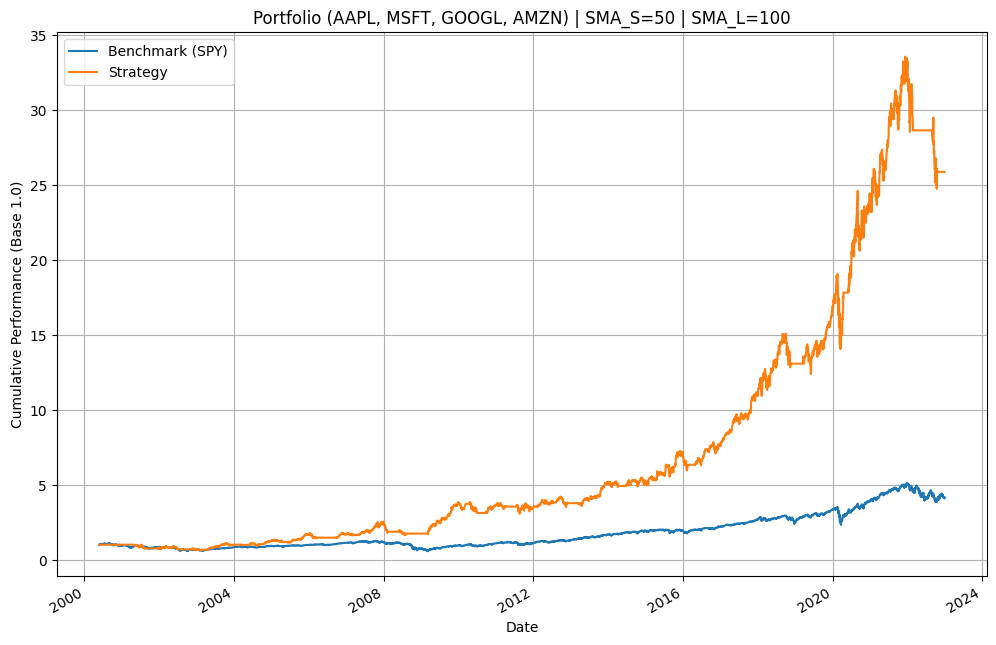

In [144]:
tester.equity_curve()

In [145]:
tester.CAGR()

Yearly Percentage Return (CAGR): 15.48%


In [146]:
tester.simple_alpha()

Annualized Simple Alpha: 8.9805%


In [147]:
tester.beta()

Beta: 0.5922


In [148]:
tester.CAPM_alpha()

Annualized Alpha (CAPM-Adjusted): 10.4079%


In [149]:
tester.max_drawdown()

Maximum Drawdown: -36.79%
